<table align="left">
  <td>
    <a href="https://githubtocolab.com/flightcomp/eia/blob/main/moia/digitos_mlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a href="https://kaggle.com/notebooks/welcome?src=https://github.com/flightcomp/eia/blob/main/moia/digitos_mlp.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" width="115"/></a>
  </td>
</table>

---

# **Licencia**

**Autor**: Roberto Chao Polo

**Licencia**: GPL v3 (https://www.gnu.org/licenses/gpl-3.0.html)


# **Reconocimientos**

* Fran Puentes Calvo

---

## Clasificador de dígitos con MLP de scikit learn

### Cargar el dataset
Descarga el dataset MNIST digits y cárgalo en memoria en un dataframe. Muestra un ejemplo de 10 imágenes y su correspondiente etiqueta, todo ello en una fila.

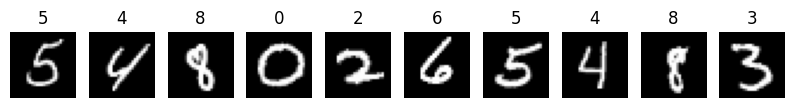

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import joblib

mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist["data"], mnist["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Muestra un ejemplo de 10 imágenes y su correspondiente etiqueta
fig, axes = plt.subplots(1, 10, figsize=(10, 1))
for i in range(10):
  image = X_train[i].reshape(28, 28)
  axes[i].imshow(image, cmap='gray')
  axes[i].set_title(y_train[i])
  axes[i].axis('off')
plt.show()


Usando una red neuronal convolucional entrena un modelo usando el conjunto de entrenamiento. Si así lo consideras, usa “cross validation” para mostrar una evaluación sin usar el conjunto de testeo.

In [2]:
import numpy as np
from sklearn.neural_network import MLPClassifier

# Normalize pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0

# Define the model
model = MLPClassifier(hidden_layer_sizes=(128,64,))
model.fit(X_train, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(128, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",200
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",None


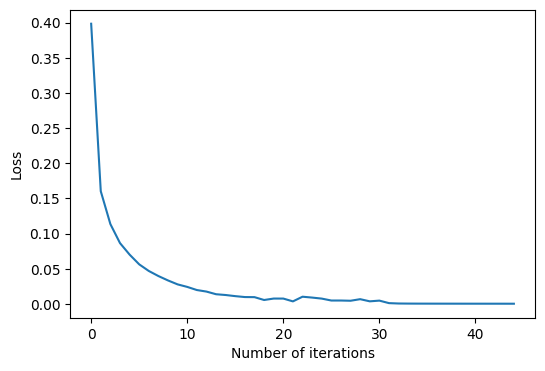

In [3]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(model.loss_curve_)
ax.set_xlabel('Number of iterations')
ax.set_ylabel('Loss')
plt.show()

In [6]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.9777857142857143

### Salvar el modelo

In [8]:
# prompt: Guarda el modelo en un fichero de tal manera que pueda recuperarlo más tarde. Muestra un ejemplo de cómo leerlo.
model_info = {  
    'model': model, 
    'training_date': '2024-12-06'  
}
joblib.dump(model_info, "data/modelo_mnist.pkl", compress=3)

['data/modelo_mnist.pkl']

### Cargar el modelo

In [3]:
model_info = joblib.load("data/modelo_mnist.pkl")
model = model_info["model"]
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.9757857142857143

### Matriz de confusión

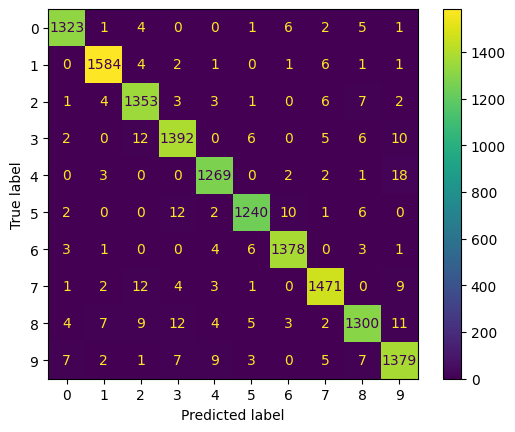

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

Usando este modelo búsca los casos en donde el modelo se confunde. Muestra en dichos casos la imagen y su etiqueta. np.where devuelve una tupla de arrays una para los índices de las filas y otra para los índices de las columnas aunque aquí no se le pasan matrices 2D si no un vector de hace así para mantener la consistencia

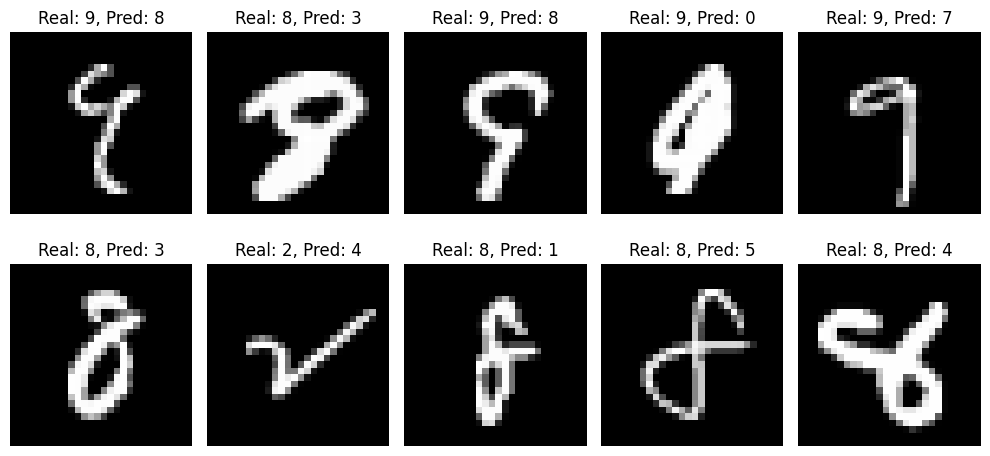

In [4]:
import matplotlib.pyplot as plt
import numpy as np
# Encuentra los casos donde el modelo se confunde
confundidos = np.where((y_test != y_pred))[0][:10]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
  idx = confundidos[i]
  image = X_test[idx].reshape(28, 28)
  ax.imshow(image, cmap='gray')
  ax.set_title(f'Real: {y_test[idx]}, Pred: {y_pred[idx]}')
  ax.axis('off')

plt.tight_layout()
plt.show()
